# Lab: Extreme Events

## Modeling the Unusual

- For a given sample, the maximum and minimum are fixed
- But if we have a large number of samples, we can study the distribution/density of those max/min draws
- Imagine:
    - The biggest storm in a year
    - The worst loss for the market in a month
    - The biggest earthquake in a decade
    - The longest time between goals in a game
- This is how we understand the distribution/density of extreme events
- The **$k$-th order statistic** is the $k$-th largest value in a sample of $n$ from some distribution
- The minimum is the first order statistic and the maximum is the $n$-th order statistic

## Example: Drawing from a Gaussian

Below, we find the minimum of a sample of size n drawn from a normal distribution, and then repeat this b times, to get a distribution of the minimum with 10000 counts in it. This is the distribution of the 1st order statistic, shown below in blue.

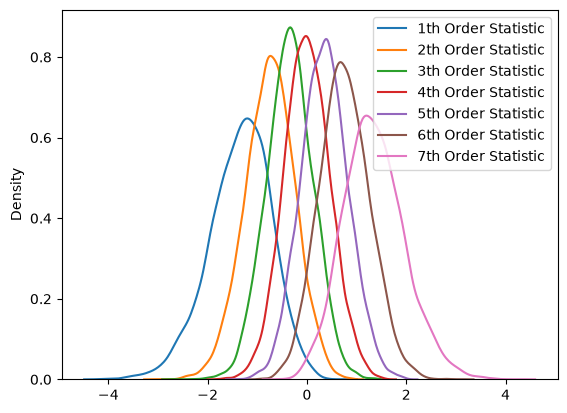

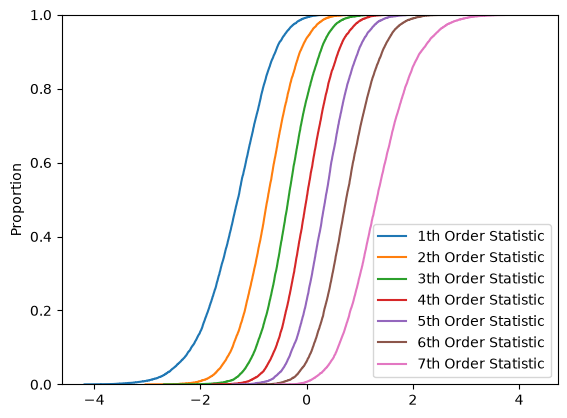

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

rng = np.random.default_rng( seed = 100 ) # Create a random number stream

n = 7 # Sample Size
b = 10_000 # Number of Simulations

sample = rng.standard_normal( size = (n,b) ) # Draw a sample from the standard normal distribution
sorted_sample = np.sort(sample, axis=0) # Sort each column (each simulated sample of size n)

for j in range(n): # For each rank
    sns.kdeplot( sorted_sample[j,:], label=f'{1+j}th Order Statistic') # Plot the KDE
plt.legend() # Add legend
plt.show()

for j in range(n): # For each rank
    sns.ecdfplot( sorted_sample[j,:], label=f'{1+j}th Order Statistic') # Plot the ECDF
plt.legend() # Add legend
plt.show()

## Analytic Relationship

### Maximum
If $F(x)$ is the underlying true CDF, let's consider the analytical equation for the distribution of the maximum of a sample of size $n$. (The maximum is its own random variable, with its distribution plotted above. What is this in math?) To build the CDF of the maximum, we ask (as always): "What's the probability the maximum lands at or below x?" for every x. In other words:
$$F_{max}(x) = P(X_{max} \leq x)$$

This is nothing new, just applying it to the distribution of a specific order statistic, the max.

So what is the **probability that all of the draws are less than or equal to $x$**, i.e. what is the probability that the maximum is less than or equal to $x$ (the right hand side)? Because each draw is independent:

$$P(X_1 \leq x \land ... \land X_n \leq x) = P( X_1 \leq x) \cdot P( X_2 \leq x ) \cdot ... \cdot  P( X_n \leq x)$$

Because we are pulling from the same distribution every time, **each of these probabilities equals our CDF, $F(x)$**:

$$P(X_1 \leq x, ..., X_n \leq x) = F(x) \cdot F(x) ... \cdot F(x)$$

The probability that all of the draws are less than or equal to x is therefore:

$$ F_{\max}(x) = F(x) \cdot F(x) \cdots F(x) = F(x)^n $$

What is its density?

## Minimum
The distribution of the minimum is somewhat harder, because our CDF is asking $\leq x$, and "max $\leq x$" means "all $\leq x$" but "min $\leq x$" does not mean "all $\leq x$". We can't just substitute in multiple copies of $F(x)$.  Instead of looking at the probability that all draws are less than or equal to $x$, we need to know the probability that at least one is.

We want to ask "is the minimum less than or equal to x?" which is the opposite of asking "are all of the draws, including the minimum, above x?" The probability that all observations are above $x$ is $(1-F(x))^{n}$. Because this is the opposite of the question we actually want to ask, the complementary probability is what we truly want:

$$ F_{min}(x) = 1 - (1-F(x))^n $$

What is its density?

## All of the other order statistics, generally
- If you're curious, the density of the $k$-th of $n$ order statistics is

$$
f_k(x) = \dfrac{n!}{(k-1)!(n-k)!} F(x)^{k-1} (1-F(x))^{n-k}f(x)
$$

- We'll use the results for the minimum and maximum

## The Data

We have three datasets:

1. Rainfall *totals* for every state-month from 1981 to 2025, with 5 reporting stations per state each month
2. Rainfall for every *station-day* over that same 1981-2025 period (same 5 stations per state) — much bigger, and used for a single question near the end of Step One
3. Daily and monthly U.S. stock market returns from 1926 to 2026

We want to understand tail behavior, to better reason about risk (engineering, financial, etc.).


In [2]:
df = pd.read_parquet("data/ghcn_prcp_monthly.parquet")
df.head()

,state,state_name,station_rank,station_id,station_name,latitude,longitude,elevation_m,year,month,month_start,prcp_total_mm,observed_total_mm,observed_days,days_in_month,coverage_fraction,prorated,imputed
0,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,1,1981-01-01,5.900001,5.900001,31,31,1.0,False,False
1,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,2,1981-02-01,1.600000,1.600000,28,28,1.0,False,False
2,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,3,1981-03-01,0.900000,0.900000,31,31,1.0,False,False
3,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,4,1981-04-01,5.100000,5.100000,30,30,1.0,False,False
4,AK,Alaska,1,USW00027502,BARROW AP,71.2869,-156.7394,8.2,1981,5,1981-05-01,1.700000,1.700000,31,31,1.0,False,False


**Step One.** 
1. Plot the ECDF and KDE of `prcp_total_mm` with seaborn— the distribution and density of rainfall across the entire U.S.

[Text(0.5, 1.0, 'KDE of Precipitation Total mm')]

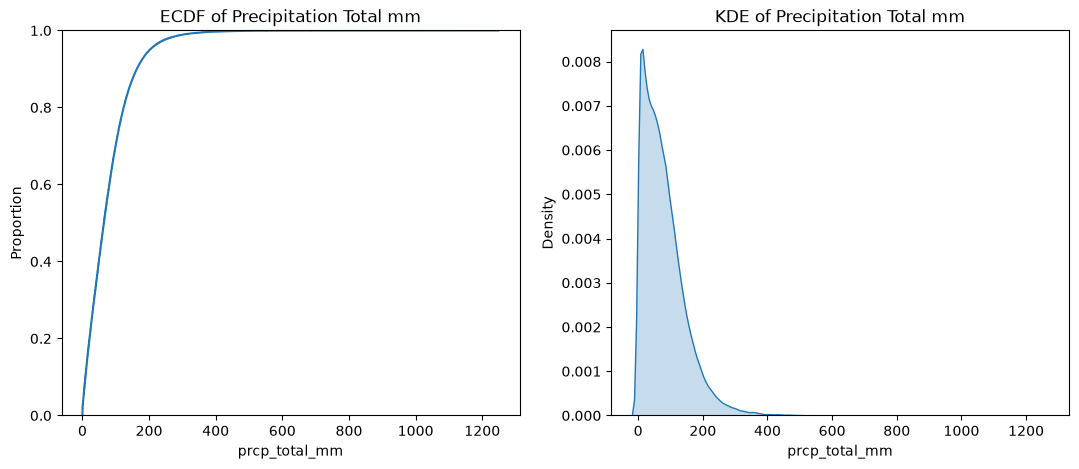

In [15]:
fig, axes = plt.subplots(1,2, figsize=(13, 5), sharex=False)
sns.ecdfplot(data = df, x = "prcp_total_mm", ax=axes[0]).set(title='ECDF of Precipitation Total mm')
sns.kdeplot(data = df, x = 'prcp_total_mm', fill = True, ax=axes[1]).set(title='KDE of Precipitation Total mm')

2. Now group by year-month and compute the **median** and **maximum** precipitation nationwide. Plot the ECDF and KDE of these two statistics.

[Text(0.5, 1.0, 'KDE of Mean Precipitation Total mm')]

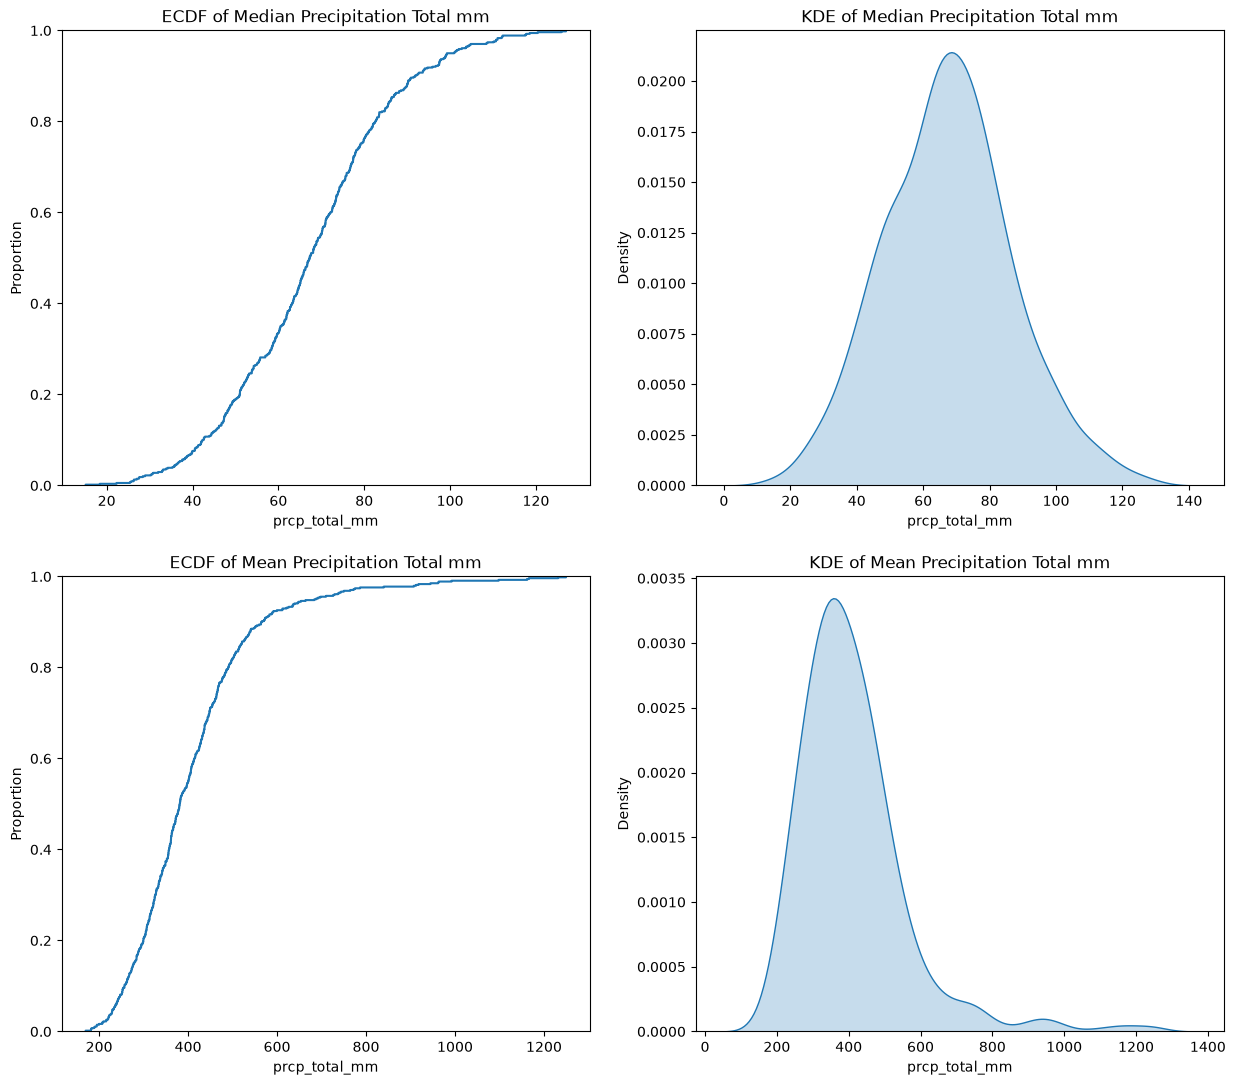

In [27]:
year_month = df.groupby(['year', 'month'])['prcp_total_mm']
median = pd.DataFrame(year_month.median())
max = pd.DataFrame(year_month.max())

fig, axes = plt.subplots(2,2, figsize=(15, 13), sharex=False)
sns.ecdfplot(data = median, x = "prcp_total_mm", ax=axes[0, 0]).set(title='ECDF of Median Precipitation Total mm')
sns.kdeplot(data = median, x = 'prcp_total_mm', fill = True, ax=axes[0, 1]).set(title='KDE of Median Precipitation Total mm')

sns.ecdfplot(data = max, x = "prcp_total_mm", ax=axes[1, 0]).set(title='ECDF of Mean Precipitation Total mm')
sns.kdeplot(data = max, x = 'prcp_total_mm', fill = True, ax=axes[1, 1]).set(title='KDE of Mean Precipitation Total mm')

3. How do your results in part 2 compare to your results in part 1?

<div class="alert alert-info">Compare and contrast the ECDFs and KDEs from parts 1 and 2. Explain why they are different:</div>

Looking at our plots, the distributions of the ECDFs are different. Our plots in part 1 showed an exponential distribution, but the distribution of the median appears to be a normal distribution and the distribution of the maximum appears to be a lognormal distribution.

4. Now define a state's rainfall differently: take the **median** of the 5 stations in each month, then find the **maximum** across the state's 12 months in a year — the "wettest month." For each state, what's the expected value of the wettest month? Plot the ECDF of Virginia's annual maxima (the wettest month in each of the 45 years), and overlay the analytical prediction $F_{\max}(x) = \hat F(x)^{12}$.

In [ ]:
# One rainfall value per state-month, taking the median of the stations
state_month =  # TODO median calculation

# Maximum of the 12 state-month observations above, for each year: the wettest month of that year
state_year_max = # TODO max calculation

exp_wettest = state_year_max.groupby("state", as_index=False).agg(E_wettest_month=("prcp_total_mm", "mean"))
exp_wettest.loc[exp_wettest["state"] == "VA"]


state = "VA"

levels = (
    state_month.loc[state_month["state"] == state, "prcp_total_mm"]
    .to_numpy()
)

observed_max = (
    state_year_max.loc[state_year_max["state"] == state, "prcp_total_mm"]
    .to_numpy()
)

x = np.sort(np.unique(levels))
F_hat = np.searchsorted(np.sort(levels), x, side="right") / len(levels)

plt.step(
    x,
    F_hat**12,
    where="post",
    label=r"Predicted: $\hat F(x)^{12}$"
)

sns.ecdfplot(x=observed_max,
    label="Observed annual maxima")

plt.xlabel("State monthly rainfall (mm)")
plt.ylabel("Cumulative probability")
plt.title(f"Annual maximum monthly rainfall: {state}")
plt.legend()
plt.show()

<div class="alert alert-info">How close is the fit here? If it differs from question 4's fit, why:</div>

5. **A question for FEMA.** So far you've worked with *monthly* rainfall totals. Switch now to the daily station-level file (`ghcn_prcp_daily.parquet`) — reload `df` from it, and don't mix it with the monthly data above.

   A day with more than 120mm of rain is a serious flood/landslide risk. On any single station-day, that's rare. But a state doesn't get one chance a month — it gets 5 stations $\times$ (days in the month) chances. FEMA doesn't care about the average day, or the single worst day on record; it cares about the probability that *some* station has a disaster day at some point during the month.

   For each state-month, estimate
   $$P(\text{at least one station-day exceeds 120mm}) = 1 - \hat F(120)^n$$
   where $\hat F$ is the empirical CDF of a single station-day's rainfall for that state and calendar month (pooled across all years), and $n$ is the number of station-days in one occurrence of that month (5 stations $\times$ days in the month). Report the 20 highest-risk state-months.


In [ ]:
# Fresh load -- this question uses only the daily file, not the monthly one above.
#df_daily = pd.read_parquet("data/ghcn_prcp_daily.parquet")

url = (
    "https://www.dropbox.com/scl/fi/"
    "pjmyop3fqjdy8oabkc4ab/ghcn_prcp_daily.parquet"
    "?rlkey=otxenczb3pxgzz53kc1i5zxww&dl=1"
)
df_daily = pd.read_parquet(url)
df_daily = df_daily.loc[df_daily["observed"]]

threshold = 120  # mm in a single day

def disaster_risk(group):
    F_hat = (group["prcp_mm"] <= threshold).mean()
    n = len(group) / group["year"].nunique()  # station-days in one year's occurrence of this month
    return 1 - F_hat**n

risk = (
    df_daily.groupby(["state", "month"])
            .apply(disaster_risk, include_groups=False)
            .rename("p_any_station_day_exceeds_120mm")
            .reset_index()
            .sort_values("p_any_station_day_exceeds_120mm", ascending=False)
)

sns.kdeplot(risk['p_any_station_day_exceeds_120mm'])

risk.head(20)

<div class="alert alert-info">Which states and months face the most risk of a greater-than-120mm day? How high is the probability? Among all state-months, describe the density of high precipitation days:<div>

**Step Two.**

Our second data set is daily and monthly U.S. stock market returns. Instead of storms across space (five stations in a state) or across the calendar (twelve months in a year), the "sample" is the set of trading days within a month, and we ask about the best and worst day in that sample.

In [ ]:
df = pd.read_parquet("data/ff_market_daily.parquet")

print(f"{len(df):,} trading days")
print(f"{df['date'].min().date()} through {df['date'].max().date()}")
df.head()

1. Plot the KDE and ECDF of daily market returns.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    data=df,
    x="market_return_pct",
    cut=0,
    ax=axes[0],
)
axes[0].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[0].set(
    title="KDE of daily U.S. market returns",
    xlabel="Daily market return (%)",
    ylabel="Estimated density",
)

sns.ecdfplot(
    data=df,
    x="market_return_pct",
    ax=axes[1],
)
axes[1].axvline(0, color="black", linewidth=1, alpha=0.6)
axes[1].set(
    title="ECDF of daily U.S. market returns",
    xlabel="Daily market return (%)",
    ylabel="Cumulative probability",
)

plt.tight_layout()
plt.show()

2. For each calendar month, compute the **best** (max) and **worst** (min) daily return — the first and $n$-th order statistics of that month's trading days. Plot the KDE of the monthly best and worst returns, overlaid.

In [ ]:
monthly = (
    df.groupby(["year", "month"], as_index=False)
         .agg(
             month_start=("month_start", "first"),
             trading_days=("date", "size"),
             worst_return_pct=("market_return_pct", "min"),
             best_return_pct=("market_return_pct", "max"),
             median_return_pct=("market_return_pct", "median"),
         )
)

# Put losses and gains on the same positive-magnitude scale.
monthly["worst_loss_pct"] = -monthly["worst_return_pct"]

print(f"{len(monthly):,} calendar months")
print(
    f"Trading days per month: {monthly['trading_days'].min()} "
    f"to {monthly['trading_days'].max()}"
)
monthly.head()

In [ ]:
plt.figure(figsize=(9, 5))
sns.kdeplot(
    x=monthly["worst_return_pct"],
    label="Worst daily return in month",
    cut=0,
)
sns.kdeplot(
    x=monthly["best_return_pct"],
    label="Best daily return in month",
    cut=0,
)
plt.axvline(0, color="black", linewidth=1, alpha=0.6)
plt.xlabel("Daily market return (%)")
plt.ylabel("Estimated density")
plt.title("Monthly worst and best daily returns")
plt.legend()
plt.show()

<div class="alert alert-info">Describe the symmetry (or lack of it) between the best- and worst-day densities. Compare them to the overall populations of daily returns. Use code as appropriate to make these comparisons, and then write out your answer in a markdown cell.</div>

3. Losses and gains are on opposite sides of zero, which makes them hard to compare directly. Put them on the same scale by looking at the *magnitude* of the worst loss (`-worst_return_pct`) against the magnitude of the best gain (`best_return_pct`). Plot both the KDE and ECDF.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.kdeplot(
    x=monthly["worst_loss_pct"],
    label="Worst loss magnitude",
    cut=0,
    ax=axes[0],
)
sns.kdeplot(
    x=monthly["best_return_pct"],
    label="Best gain",
    cut=0,
    ax=axes[0],
)
axes[0].set(
    title="KDE: magnitudes of monthly extremes",
    xlabel="Return magnitude (%)",
    ylabel="Estimated density",
)
axes[0].legend()

sns.ecdfplot(
    x=monthly["worst_loss_pct"],
    label="Worst loss magnitude",
    ax=axes[1],
)
sns.ecdfplot(
    x=monthly["best_return_pct"],
    label="Best gain",
    ax=axes[1],
)
axes[1].set(
    title="ECDF: magnitudes of monthly extremes",
    xlabel="Return magnitude (%)",
    ylabel="Cumulative probability",
)
axes[1].legend()

plt.tight_layout()
plt.show()

<div class="alert alert-info">Are large losses more extreme than large gains, or about the same:</div>

4. Compute the median, 75th, 90th, 95th, and 99th percentile of both magnitudes from question 3. In what fraction of months does the worst loss exceed the best gain in magnitude?

In [ ]:
tail_summary = pd.DataFrame(
    {
        "Worst loss magnitude": monthly["worst_loss_pct"],
        "Best gain": monthly["best_return_pct"],
    }
).quantile([0.50, 0.75, 0.90, 0.95, 0.99]).T

tail_summary.columns = ["median", "75%", "90%", "95%", "99%"]

print(
    "Fraction of months in which the worst loss exceeded the best gain: "
    f"{(monthly['worst_loss_pct'] > monthly['best_return_pct']).mean():.1%}"
)
tail_summary.round(2)

<div class="alert alert-info">What does this tail comparison say about the risk of losses vs. gains:</div>

5. Plot the monthly best and worst daily returns over time. Do the extremes look stable across this ~100-year history, or are there periods where they're much larger? Can you identify any famous market events?

In [ ]:
plt.figure(figsize=(13, 5))
plt.plot(
    monthly["month_start"],
    monthly["best_return_pct"],
    linewidth=0.8,
    label="Best day",
)
plt.plot(
    monthly["month_start"],
    monthly["worst_return_pct"],
    linewidth=0.8,
    label="Worst day",
)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Month")
plt.ylabel("Daily market return (%)")
plt.title("Monthly market extremes through time")
plt.legend()
plt.show()

<div class="alert alert-info">Do upside and downside risk tend to go together (volatility), or does the market exhibit distinct periods in which the good shocks are concentrated and the bad shocks are concentrated? What implication does this have for investing?:</div> 

## Wrap-up



<div class="alert alert-info">This week has focused on kernel density estimation, particularly estimating the PDF from data. This lab takes that a step further: We can estimate and quantify the densities and distributions of random variables that build off of observed phenomena. What is the difference between the ECDF and KDE? Explain how these estimations today give us different information than an ECDF or KDE plot of the underlying data, but quantify information about the behavior of a different random variable.</div>